In [ ]:
import cv2
import numpy as np

from PIL import Image
from IPython.display import display

import skimage as ski


def show(img_rgb, scale_factor=0.25):
    # if greyscale, convert to RGB
    if len(img_rgb.shape) == 2:
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_GRAY2RGB)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    scaled_img = cv2.resize(img_rgb, (img_rgb.shape[1] // int(1/scale_factor), img_rgb.shape[0] // int(1/scale_factor)))
    display(Image.fromarray(scaled_img))
    return

video_source = r"uploads\IMG_1759.MOV"  # Change this to your video file path or camera index

cap = cv2.VideoCapture(video_source)
_ret, cap_1 = cap.read()  # Read the first frame to check if the video is valid

# get frame number 32
cap.set(cv2.CAP_PROP_POS_FRAMES, 32)
_ret, cap_32 = cap.read()
# cap_32 = cap_32[cap_32.shape[0]//4:cap_32.shape[0], :]  # crop to bottom 3/4ths
# cap_32 = cv2.imread(r"uploads\frames\frame_0011.png")  # for testing purposes, use a saved frame instead of the video frame

show(cap_1)
show(cap_32)
print(f"Resolution: {cap_1.shape}, FPS: {cap.get(cv2.CAP_PROP_FPS)}, Total Frames: {cap.get(cv2.CAP_PROP_FRAME_COUNT)}, duration: {cap.get(cv2.CAP_PROP_FRAME_COUNT) / cap.get(cv2.CAP_PROP_FPS)} seconds")

Starting the idolating sclera stuff

In [ ]:
import numpy as np

# cap_32_blur = cv2.blur(cap_32, (51, 51))
aspect_ratio = cap_32.shape[1] / cap_32.shape[0]
new_w = 500
if new_w > cap_32.shape[1]:
    new_w = int(cap_32.shape[1] * .25)
new_h = int(new_w / aspect_ratio)

cap_32_lowRes = cv2.resize(cap_32, (new_w, new_h), interpolation=cv2.INTER_AREA)
# cap_32_lowRes = cap_32_lowRes[new_h//4:new_h, :]  # crop to bottom 3/4ths
show(cap_32_lowRes)

In [ ]:
cap_32_hsv = cv2.cvtColor(cap_32_lowRes, cv2.COLOR_BGR2HSV)

thresh_hsv = cv2.inRange(cap_32_hsv, (0, 1, 180), (180, 35, 255))
opened_hsv = cv2.morphologyEx(thresh_hsv, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))
close_hsv = cv2.morphologyEx(opened_hsv, cv2.MORPH_CLOSE, np.ones((11,11), np.uint8))
larg_Contour, _ = cv2.findContours(close_hsv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(larg_Contour, key=cv2.contourArea) if larg_Contour else None
peri = cv2.arcLength(largest_contour, True)
simplified_contour = cv2.approxPolyDP(largest_contour, epsilon=0.015 * peri, closed=True)
#  get the corresponding mask of the largest contour
mask = np.zeros_like(close_hsv)
mask = cv2.drawContours(mask, [simplified_contour], -1, 255, thickness=cv2.FILLED)
    
show(thresh_hsv)
show(opened_hsv)
show(close_hsv)
show(mask)


In [ ]:

# Take the contour coords and multiply by a transformation matrix to get the corresponding coords in the original image, then draw the contour on the original image
M = np.array([[cap_32.shape[1] / new_w, 0, 0],
              [0, cap_32.shape[0] / new_h, 25],
              [0, 0, 1]])

# make the contour coords homogeneous
# take out one of the wrappers for the contour coords
homogeneous_coords = np.hstack([largest_contour.reshape(-1, 2), np.ones((largest_contour.shape[0], 1))])
print(f"homogeneous coords shape: {homogeneous_coords.shape} and values: {homogeneous_coords[:5]}")
transformed_coords = (M @ homogeneous_coords.T).T[:, :2].astype(int)

# draw the contour on the original image
contour_img = cap_32.copy()
contour_zero = np.zeros_like(contour_img)
mask = cv2.drawContours(contour_zero, [transformed_coords], -1, 255, thickness=cv2.FILLED)
contour_img = cap_32 * mask.astype(bool)
print(f"contour_img shape: {contour_img.shape}")

#debugging code to look for good pixels
nonzero_mask = np.any(contour_img != 0, axis=2)  # shape: (1080, 1280)
rows, cols = np.where(nonzero_mask)

print(f"contour_img pixel at ({rows[0:5]}, {cols[0:5]}): {contour_img[rows[0:5], cols[0:5]]}")
# print(f"contour_img values: {np.unique(contour_img)}") # use numpy to show me a pixel with values
print(f"mask shape: {mask.shape} cap_32.shape: {cap_32.shape}")
show(contour_img)


show(mask)


OK so that was all the sclera stuff, this going to optimizing the stabilization

In [6]:
#close the first video capture
# cap.close()
# cap.release()
def show(img_rgb, scale_factor=0.25):
    # if greyscale, convert to RGB
    if len(img_rgb.shape) == 2:
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_GRAY2RGB)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    scaled_img = cv2.resize(img_rgb, (img_rgb.shape[1] // int(1/scale_factor), img_rgb.shape[0] // int(1/scale_factor)))
    display(Image.fromarray(scaled_img))
    return


import os
from CV_steps.sclera import sclera_pipeline
from PIL import Image


# cap = cv2.VideoCapture(video_source)
video_source = r"uploads\IMG_1759.MOV"  # Change this to your video file path or camera index

testing_out = os.path.join("output", "jupyter_test")
os.makedirs(testing_out, exist_ok=True)
print(f"Testing output directory: {testing_out}")

outlined_path = os.path.join(testing_out, "sclera_outline.mp4")
mask_path = os.path.join(testing_out, "sclera_mask.mp4")

# sclera_pipeline(str(video_source), outlined_path, mask_path, max_workers=8)

Testing output directory: output\jupyter_test


In [ ]:
from CV_steps.stabilize import stabilize_video


stabilize_video(mask_path, os.path.join(testing_out, f"sclera_mask_stabilized.mp4"))

# try a bunch of different smoothing radius values and see how it looks
# for radius in [10, 20, 30, 50, 75, 100]:
#     stabilize_video(mask_path, os.path.join(testing_out, f"sclera_mask_stabilized_{radius}.mp4"), smoothing_radius=radius)
#     print(f"Stabilized video with radius {radius} saved to {os.path.join(testing_out, f'sclera_mask_stabilized_{radius}.mp4')}")

# Also test stabilizing then isolating the sclear

# stab_path = os.path.join(testing_out, f"video_stabilized.mp4")
# stabilize_video(video_source, stab_path, smoothing_radius=50)

# sclera_pipeline(stab_path, os.path.join(testing_out, f"video_stabilized_sclera_outline.mp4"), os.path.join(testing_out, f"video_stabilized_sclera_mask.mp4"), max_workers=8)

In [7]:
# Import numpy and OpenCV
import numpy as np
import cv2
 
# Read input video
cap = cv2.VideoCapture(mask_path)
 
# Get frame count
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
 
# Get width and height of video stream
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
 
# Define the codec for output video
fourcc = cv2.VideoWriter_fourcc(*'MJPG')


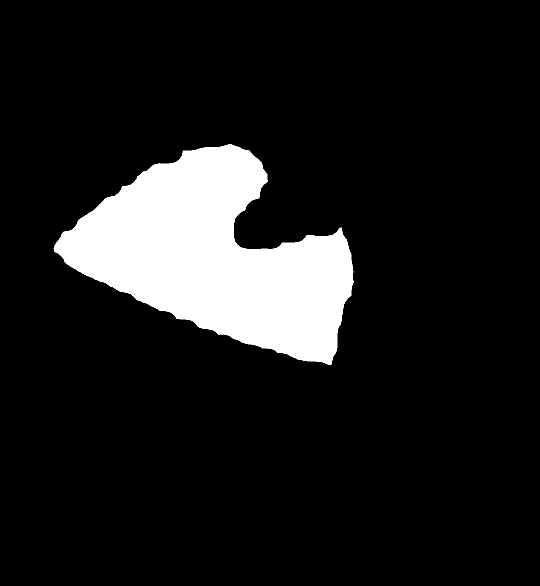

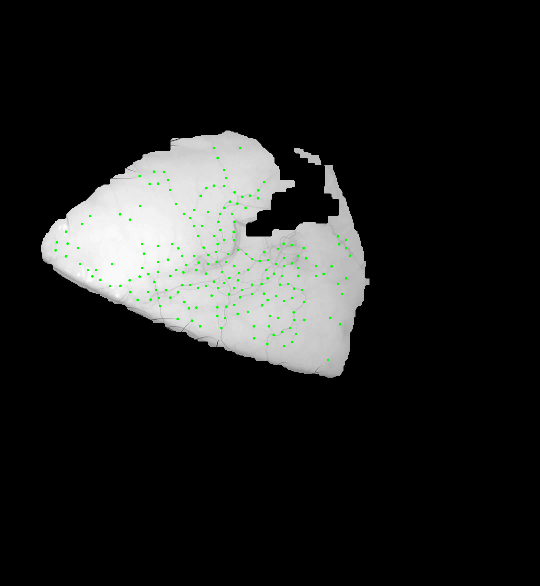

In [8]:
# Read first frame
_, prev = cap.read()
 
# Convert frame to grayscale
prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

# show features detected in the first frame
# make a mask of all the current data and then erode it shrink it
mask = cv2.threshold(prev_gray, 1, 255, cv2.THRESH_BINARY)[1]
# somehow shrink the mask

# kernel = np.ones((5,5), np.uint8)
# mask = cv2.erode(mask, kernel, iterations=5)

dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5) # calculate distance from edge for each pixel
mask = (dist > 50).astype(np.uint8) * 255  # keep only pixels >50px from any edge

show(mask)
features = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200, qualityLevel=0.01, minDistance=30, blockSize=3, mask=mask)
features = np.intp(features)

featured_prev = cv2.cvtColor(prev_gray, cv2.COLOR_GRAY2BGR)
for feature in features:
    x, y = feature.ravel()
    cv2.circle(featured_prev, (x, y), 5, (0, 255, 0), -1)

show(featured_prev)



In [12]:
import os
import numpy as np
import cv2
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
mask_path   = Path(r"C:\Users\dragon\Code\CatsEye-Python\output\results_20260502-014013\sclera_overlay.mp4")
testing_out = Path(r"C:\Users\dragon\Code\CatsEye-Python\output\testing_sclera")
testing_out.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
FEATURE_PARAMS = dict(maxCorners=200, qualityLevel=0.01, minDistance=30, blockSize=3)
LK_PARAMS      = dict(winSize=(21, 21), maxLevel=3,
                      criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))
EDGE_MARGIN    = 50   # px from any non-zero edge to exclude
REDETECT_EVERY = 30   # re-detect corners every N frames


# ── Helpers ───────────────────────────────────────────────────────────────────
def build_feature_mask(gray: np.ndarray, margin: int = EDGE_MARGIN) -> np.ndarray:
    """Return a mask keeping only pixels >margin px from the sclera boundary."""
    binary = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)[1]
    dist   = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    return (dist > margin).astype(np.uint8) * 255


def detect_features(gray: np.ndarray) -> np.ndarray:
    mask = build_feature_mask(gray)
    pts  = cv2.goodFeaturesToTrack(gray, mask=mask, **FEATURE_PARAMS)
    return pts.astype(np.float32) if pts is not None else np.empty((0, 1, 2), np.float32)


# ── Open video ────────────────────────────────────────────────────────────────
cap      = cv2.VideoCapture(str(mask_path))
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h        = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps      = cap.get(cv2.CAP_PROP_FPS)

out_path   = str(testing_out / "notebook_test.mp4")
out_writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
print(f"Writer ready → {out_path}  |  {w}×{h} @ {fps:.1f} fps")

# ── Bootstrap first frame ─────────────────────────────────────────────────────
ok, prev = cap.read()
if not ok:
    raise RuntimeError("Could not read first frame.")

prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)
prev_pts  = detect_features(prev_gray)

# ── Main loop ─────────────────────────────────────────────────────────────────
for frame_idx in range(1, n_frames):
    ok, img = cap.read()
    if not ok:
        print(f"Stream ended at frame {frame_idx}.")
        break

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Re-detect periodically or when we've lost too many points
    if frame_idx % REDETECT_EVERY == 0 or len(prev_pts) < 10:
        prev_pts = detect_features(prev_gray)

    if len(prev_pts) > 0:
        # Track prev_pts from prev_gray → gray
        curr_pts, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray, gray, prev_pts, None, **LK_PARAMS)

        good_old = prev_pts[status == 1]
        good_new = curr_pts[status == 1]

        if len(good_old) >= 4:
            # matrix, _ = cv2.findHomography(good_old, good_new, cv2.RANSAC, 5.0)
            matrix, _ = cv2.estimateAffinePartial2D(good_old, good_new, method=cv2.RANSAC, ransacReprojThreshold=5.0)
            if matrix is not None:
                # stabilized = cv2.warpPerspective(img, matrix, (w, h))
                stabilized = cv2.warpAffine(img, matrix, (w, h))  # use warpAffine for affine matrix
                out_writer.write(stabilized)
            else:
                print(f"Frame {frame_idx}: homography failed — writing original.")
                out_writer.write(img)
        else:
            print(f"Frame {frame_idx}: only {len(good_old)} good points — writing original.")
            out_writer.write(img)

        prev_pts = good_new.reshape(-1, 1, 2)
    else:
        print(f"Frame {frame_idx}: no trackable features — writing original.")
        out_writer.write(img)

    prev_gray = gray

# ── Cleanup ───────────────────────────────────────────────────────────────────
cap.release()
out_writer.release()
print(f"Done. Stabilized video → {out_path}")

Writer ready → C:\Users\dragon\Code\CatsEye-Python\output\testing_sclera\notebook_test.mp4  |  2160×3840 @ 59.9 fps
Frame 7: only 0 good points — writing original.
Frame 8: no trackable features — writing original.
Frame 13: only 0 good points — writing original.
Frame 32: only 0 good points — writing original.
Frame 62: no trackable features — writing original.
Done. Stabilized video → C:\Users\dragon\Code\CatsEye-Python\output\testing_sclera\notebook_test.mp4


Original image shape: (3840, 2160, 3)


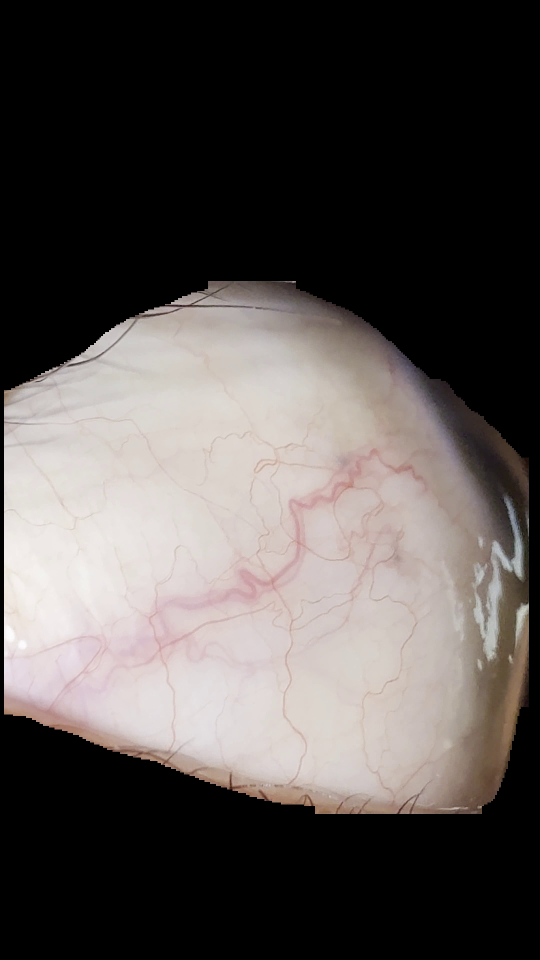

In [17]:
import cv2
import numpy as np
from PIL import Image
def show(img_rgb, scale_factor=0.25):
    # if greyscale, convert to RGB
    if len(img_rgb.shape) == 2:
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_GRAY2RGB)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    scaled_img = cv2.resize(img_rgb, (img_rgb.shape[1] // int(1/scale_factor), img_rgb.shape[0] // int(1/scale_factor)))
    display(Image.fromarray(scaled_img))
    return
input_frame = r"C:\Users\dragon\Code\CatsEye-Python\output\testing_sclera\frames\frame090.png"
off_frame = r"C:\Users\dragon\Code\CatsEye-Python\output\testing_sclera\frames\frame003.png"
img_in = cv2.imread(input_frame)
img_off = cv2.imread(off_frame)
print(f"Original image shape: {img.shape}")
show(img_in)

In [76]:
from CV_steps.XCorr import gen_mask
# import scikit-image as ski

# print(f"Mask shape: {img_in.shape}, unique values: {np.unique(img_in)}")

mask = gen_mask(img_in)
mask_off = gen_mask(img_off)
# show(mask)

# mask 

# edges = cv2.Canny(img_in, 50, 50)
img_blur = cv2.GaussianBlur(img_in, (3,3), 0)
img_blur2 = cv2.GaussianBlur(img_off, (3,3), 0)
canny = cv2.Canny(img_in, 20, 50, apertureSize=3, L2gradient=False)
canny2 = cv2.Canny(img_off, 20, 50, apertureSize=3, L2gradient=False)
laplacian = cv2.Laplacian(img_in, cv2.CV_64F, ksize=3)
laplacian_abs = cv2.convertScaleAbs(laplacian)
laplacian2 = cv2.Laplacian(img_off, cv2.CV_64F, ksize=3)
laplacian2_abs = cv2.convertScaleAbs(laplacian2)
sobelxy = cv2.Sobel(src=img_blur, ddepth=cv2.CV_64F, dx=1, dy=1, ksize=5) # Combined X and Y Sobel Edge Detection
sobel = cv2.convertScaleAbs(sobelxy)
sobelxy2 = cv2.Sobel(src=img_blur2, ddepth=cv2.CV_64F, dx=1, dy=1, ksize=5) # Combined X and Y Sobel Edge Detection
sobel2 = cv2.convertScaleAbs(sobelxy2)

ridge = cv2.ximgproc.RidgeDetectionFilter.create()
frangi = ridge.getRidgeFilteredImage(img_in)
frangi2 = ridge.getRidgeFilteredImage(img_off)
# show(canny)
# show(laplacian_abs)
# show(sobel)

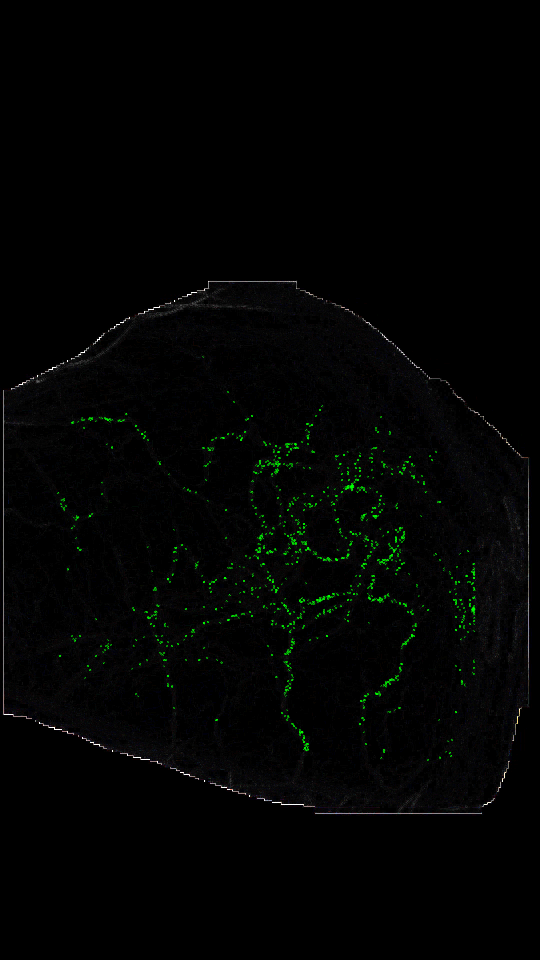

True

In [77]:
in1 = laplacian_abs
in2 = laplacian2_abs

orb = cv2.ORB_create(5000)    
bf  = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
kp1, des1 = orb.detectAndCompute(in1, mask=mask)
kp_img = cv2.drawKeypoints(in1, kp1, in1, color=(0,255,0), flags=0)
show(kp_img)
kp2, des2 = orb.detectAndCompute(in2, mask=mask_off)
# matches = bf.match(des1, des2)
# matches = sorted(matches, key = lambda x:x.distance)
matcher = cv2.DescriptorMatcher.create('BruteForce')
matches = matcher.knnMatch(des1,des2, 2)
# Filter matches using the Lowe's ratio test
ratio_thresh = 0.7
good_matches = []
for i, (m,n) in enumerate(matches):
    if m.distance < ratio_thresh * n.distance:
        good_matches.append(m)
matched = cv2.drawMatches(in1, kp1, in2, kp2, good_matches[:10], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
cv2.imwrite(r"C:\Users\dragon\Code\CatsEye-Python\output\testing_sclera\frames\feature_match.png", matched)

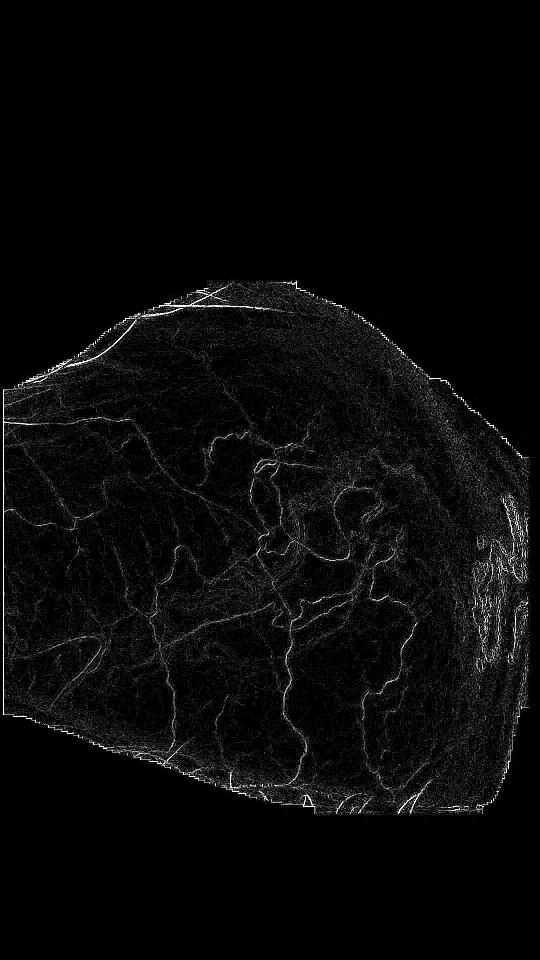

In [72]:
# frangi filter
# frangi = cv2.ximgproc.frangi(img_in, scale_range=(1, 10), scale_step=2, beta1=0.5, beta2=15)
ridge = cv2.ximgproc.RidgeDetectionFilter.create(scale=1)
frangi = ridge.getRidgeFilteredImage(img_in)
show(frangi)